In [ ]:
# Install Kaggle API
!pip -q install kaggle

In [ ]:
# Paste your Kaggle dataset URL here
kaggle_url = "https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents"

print("Kaggle dataset link added successfully!")
print(kaggle_url)

Kaggle dataset link added successfully!
https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents


In [ ]:
# Extract Kaggle dataset information from the URL

import re

match = re.search(r'kaggle\.com/datasets/([^/]+/[^/?]+)', kaggle_url)

if match:
    dataset_id = match.group(1)
    print("Dataset ID:", dataset_id)
else:
    raise ValueError("Invalid Kaggle dataset URL")

Dataset ID: sobhanmoosavi/us-accidents


In [ ]:
# Download the dataset from Kaggle

!kaggle datasets download -d {dataset_id} -p /content/accident_data

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:18<00:00, 37.4MB/s]



In [ ]:
# Extract the downloaded Kaggle dataset

import zipfile
import os

download_dir = "/content/accident_data"

zip_files = [
    f for f in os.listdir(download_dir)
    if f.endswith(".zip")
]

print("Downloaded files:", zip_files)

if zip_files:
    zip_path = os.path.join(download_dir, zip_files[0])

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(download_dir)

    print("✅ Dataset extracted successfully!")
else:
    print("❌ No ZIP file found.")

Downloaded files: ['us-accidents.zip']
✅ Dataset extracted successfully!


In [ ]:
# Find CSV files inside the extracted dataset

csv_files = []

for root, dirs, files in os.walk(download_dir):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")

for file in csv_files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    print(f"📄 {file} — {size_mb:.2f} MB")

CSV files found:
📄 /content/accident_data/US_Accidents_March23.csv — 2916.51 MB


##Memory-Efficient Data Loading

The US Accidents dataset is approximately 2.9 GB in CSV format, making it too large to safely load into memory as a single Pandas DataFrame in a standard Google Colab environment.

To handle the large dataset efficiently, the analysis will use **chunk-based processing**. The CSV will be read in smaller portions, allowing us to perform exploratory analysis and aggregate important statistics without loading the entire dataset into RAM at once.

This approach improves memory efficiency while preserving the information required for traffic pattern and accident hotspot analysis.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# Path to the extracted dataset
csv_path = "/content/accident_data/US_Accidents_March23.csv"

# Read the dataset in chunks
chunk_size = 100_000

sample_chunks = []

for chunk in pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False):
    sample_chunks.append(chunk)

    # Keep only the first few chunks for initial exploration
    if len(sample_chunks) == 3:
        break

# Combine only the sample chunks
df_sample = pd.concat(sample_chunks, ignore_index=True)

print("✅ Initial sample loaded successfully!")
print("Sample shape:", df_sample.shape)

✅ Initial sample loaded successfully!
Sample shape: (300000, 46)


In [ ]:
# Basic information about the dataset sample

print("Dataset Shape:", df_sample.shape)

print("\nNumber of Rows:", df_sample.shape[0])
print("Number of Columns:", df_sample.shape[1])

print("\nColumn Names:")
print(df_sample.columns.tolist())

Dataset Shape: (300000, 46)

Number of Rows: 300000
Number of Columns: 46

Column Names:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## Data Quality Assessment & Cleaning

Before performing exploratory data analysis, the dataset must be inspected for data quality issues.

The US Accidents dataset contains information collected from multiple sources and includes numerical, categorical, geographical, temporal, and weather-related variables.

The following data quality checks will be performed:

- Missing values
- Duplicate records
- Incorrect data types
- Invalid geographical coordinates
- Invalid accident severity values
- Invalid numerical measurements
- Missing values in important categorical and temporal features

After identifying these issues, appropriate preprocessing steps will be applied to prepare the data for reliable analysis and visualization.

In [ ]:
# Check data types
print("📋 Data Types:\n")
print(df_sample.dtypes)

print("\n" + "="*60)
print("Data type summary:")
print(df_sample.dtypes.value_counts())

📋 Data Types:

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     

In [ ]:
# Check duplicate rows
duplicate_count = df_sample.duplicated().sum()

print(f"🔍 Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {(duplicate_count / len(df_sample) * 100):.2f}%")

🔍 Duplicate rows: 0
Duplicate percentage: 0.00%


In [ ]:
# Missing value analysis
missing = df_sample.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df_sample)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_df[missing_df["Missing Values"] > 0])

,Missing Values,Missing Percentage
End_Lng,300000,100.000000
End_Lat,300000,100.000000
Precipitation(in),270964,90.321333
Wind_Chill(F),264385,88.128333
Wind_Speed(mph),57754,19.251333
Visibility(mi),6663,2.221000
Weather_Condition,6131,2.043667
Humidity(%),4807,1.602333
Temperature(F),4356,1.452000
Pressure(in),3513,1.171000


In [ ]:
# Display actual values of the geographic columns
df_sample[[
    "ID",
    "Start_Lat",
    "Start_Lng",
    "End_Lat",
    "End_Lng"
]].head(200)

,ID,Start_Lat,Start_Lng,End_Lat,End_Lng
0,A-1,39.865147,-84.058723,NaN,NaN
1,A-2,39.928059,-82.831184,NaN,NaN
2,A-3,39.063148,-84.032608,NaN,NaN
3,A-4,39.747753,-84.205582,NaN,NaN
4,A-5,39.627781,-84.188354,NaN,NaN
...,...,...,...,...,...
195,A-196,40.051949,-83.032806,NaN,NaN
196,A-197,39.772823,-84.135612,NaN,NaN
197,A-198,39.673203,-84.221886,NaN,NaN
198,A-199,39.762440,-84.205070,NaN,NaN


In [ ]:
# Check End_Lat and End_Lng across the COMPLETE raw CSV
geo_missing = {
    "Total Rows": 0,
    "End_Lat Missing": 0,
    "End_Lat Non-Missing": 0,
    "End_Lng Missing": 0,
    "End_Lng Non-Missing": 0
}

for chunk in pd.read_csv(
    csv_path,
    usecols=["End_Lat", "End_Lng"],
    chunksize=100_000,
    low_memory=False
):
    geo_missing["Total Rows"] += len(chunk)

    geo_missing["End_Lat Missing"] += chunk["End_Lat"].isna().sum()
    geo_missing["End_Lat Non-Missing"] += chunk["End_Lat"].notna().sum()

    geo_missing["End_Lng Missing"] += chunk["End_Lng"].isna().sum()
    geo_missing["End_Lng Non-Missing"] += chunk["End_Lng"].notna().sum()

print("📍 COMPLETE DATASET GEOGRAPHIC CHECK")
print("=" * 50)

for key, value in geo_missing.items():
    print(f"{key}: {value:,}")

📍 COMPLETE DATASET GEOGRAPHIC CHECK
Total Rows: 7,728,394
End_Lat Missing: 3,402,762
End_Lat Non-Missing: 4,325,632
End_Lng Missing: 3,402,762
End_Lng Non-Missing: 4,325,632


In [ ]:
# Complete dataset missing-value analysis
missing_counts = {}

for chunk in pd.read_csv(
    csv_path,
    chunksize=100_000,
    low_memory=False
):
    for col in chunk.columns:
        if col not in missing_counts:
            missing_counts[col] = 0
        missing_counts[col] += chunk[col].isna().sum()

total_rows = 7_728_394

complete_missing_df = pd.DataFrame({
    "Missing Values": missing_counts,
})

complete_missing_df["Missing Percentage"] = (
    complete_missing_df["Missing Values"] / total_rows * 100
)

complete_missing_df = complete_missing_df.sort_values(
    "Missing Percentage",
    ascending=False
)

display(complete_missing_df)

,Missing Values,Missing Percentage
End_Lng,3402762,44.029355
End_Lat,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143


In [ ]:
weather_check = pd.read_csv(
    csv_path,
    usecols=[
        "ID",
        "Start_Time",
        "Temperature(F)",
        "Wind_Chill(F)",
        "Humidity(%)",
        "Pressure(in)",
        "Visibility(mi)",
        "Wind_Speed(mph)",
        "Precipitation(in)",
        "Weather_Condition"
    ],
    nrows=100
)

display(weather_check)

,ID,Start_Time,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition
0,A-1,2016-02-08 05:46:00,36.9,NaN,91.0,29.68,10.0,NaN,0.02,Light Rain
1,A-2,2016-02-08 06:07:59,37.9,NaN,100.0,29.65,10.0,NaN,0.00,Light Rain
2,A-3,2016-02-08 06:49:27,36.0,33.3,100.0,29.67,10.0,3.5,NaN,Overcast
3,A-4,2016-02-08 07:23:34,35.1,31.0,96.0,29.64,9.0,4.6,NaN,Mostly Cloudy
4,A-5,2016-02-08 07:39:07,36.0,33.3,89.0,29.65,6.0,3.5,NaN,Mostly Cloudy
5,A-6,2016-02-08 07:44:26,37.9,35.5,97.0,29.63,7.0,3.5,0.03,Light Rain
6,A-7,2016-02-08 07:59:35,34.0,31.0,100.0,29.66,7.0,3.5,NaN,Overcast
7,A-8,2016-02-08 07:59:58,34.0,31.0,100.0,29.66,7.0,3.5,NaN,Overcast
8,A-9,2016-02-08 08:00:40,33.3,NaN,99.0,29.67,5.0,1.2,NaN,Mostly Cloudy
9,A-10,2016-02-08 08:10:04,37.4,33.8,100.0,29.62,3.0,4.6,0.02,Light Rain


In [ ]:
# Check for potentially invalid numerical values

checks = {
    "Negative Distance": (df_sample["Distance(mi)"] < 0).sum(),

    "Invalid Humidity (<0 or >100)": (
        (df_sample["Humidity(%)"] < 0) |
        (df_sample["Humidity(%)"] > 100)
    ).sum(),

    "Negative Visibility": (
        df_sample["Visibility(mi)"] < 0
    ).sum(),

    "Negative Wind Speed": (
        df_sample["Wind_Speed(mph)"] < 0
    ).sum(),

    "Negative Precipitation": (
        df_sample["Precipitation(in)"] < 0
    ).sum(),

    "Invalid Latitude": (
        (df_sample["Start_Lat"] < -90) |
        (df_sample["Start_Lat"] > 90)
    ).sum(),

    "Invalid Longitude": (
        (df_sample["Start_Lng"] < -180) |
        (df_sample["Start_Lng"] > 180)
    ).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

Negative Distance: 0
Invalid Humidity (<0 or >100): 0
Negative Visibility: 0
Negative Wind Speed: 0
Negative Precipitation: 0
Invalid Latitude: 0
Invalid Longitude: 0


In [ ]:
print("Duplicate IDs:", df_sample["ID"].duplicated().sum())
print("Missing IDs:", df_sample["ID"].isna().sum())
print("Severity values:", sorted(df_sample["Severity"].unique()))

Duplicate IDs: 0
Missing IDs: 0
Severity values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
end_time_check = pd.to_datetime(
    df_sample["End_Time"],
    errors="coerce"
)

print("Invalid Start_Time values:", df_sample["Start_Time"].isna().sum())
print("Invalid End_Time values:", end_time_check.isna().sum())

print("\nStart date range:")
print(df_sample["Start_Time"].min(), "to", df_sample["Start_Time"].max())

print("\nEnd date range:")
print(end_time_check.min(), "to", end_time_check.max())

Invalid Start_Time values: 0
Invalid End_Time values: 0

Start date range:
2016-02-08 05:46:00 to 2017-01-26 20:28:01

End date range:
2016-02-08 06:37:59 to 2017-01-26 20:57:34


In [ ]:
duration = (
    end_time_check - df_sample["Start_Time"]
).dt.total_seconds() / 60

print("Accident duration statistics (minutes):")
print(duration.describe())

print("\nNegative durations:", (duration < 0).sum())
print("Zero-duration accidents:", (duration == 0).sum())

/tmp/ipykernel_2914/1956654234.py:2: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  end_time_check - df_sample["Start_Time"]


TypeError: unsupported operand type(s) for -: 'Timestamp' and 'str'

## 🧹 Data Cleaning Strategy

The data quality assessment identified no invalid values in the major numerical, geographic, identifier, or datetime fields examined in the initial 300,000-row sample.

Therefore, the cleaning process will follow a **minimal and evidence-based approach** rather than aggressively removing records.

The following principles will be applied:

- Preserve the original raw dataset unchanged.
- Retain all valid accident records.
- Do not remove rows simply because some optional fields contain missing values.
- Keep `End_Lat` and `End_Lng` because they are available for a substantial portion of the dataset and can support route/location analysis.
- Retain missing weather measurements where they are genuinely unavailable.
- Do not automatically replace missing precipitation values with `0`, because missing precipitation and measured zero precipitation are different situations.
- Standardize datetime columns for reliable time-based analysis.
- Use `"Unknown"` for missing categorical values only when required for grouping or visualization.
- Handle numerical missing values through appropriate imputation only if they are required for a future machine-learning model.

This approach minimizes information loss while producing a reliable dataset for exploratory analysis, accident pattern analysis, and hotspot detection.

In [ ]:
# Create a copy of the sample for cleaning
df_clean = df_sample.copy()

# --------------------------------------------------
# 1. Standardize datetime columns
# --------------------------------------------------

df_clean["Start_Time"] = pd.to_datetime(
    df_clean["Start_Time"],
    errors="coerce"
)

df_clean["End_Time"] = pd.to_datetime(
    df_clean["End_Time"],
    errors="coerce"
)

# --------------------------------------------------
# 2. Handle categorical missing values
# --------------------------------------------------

categorical_columns = [
    "Street",
    "City",
    "Zipcode",
    "Timezone",
    "Airport_Code",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

# --------------------------------------------------
# 3. Handle text missing values
# --------------------------------------------------

df_clean["Description"] = df_clean["Description"].fillna("Unknown")

print("✅ Cleaning completed successfully!")
print("Cleaned shape:", df_clean.shape)

✅ Cleaning completed successfully!
Cleaned shape: (300000, 46)


In [ ]:
print("Remaining missing values after cleaning:")
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

display(
    pd.DataFrame({
        "Missing Values": remaining_missing,
        "Missing Percentage": (
            remaining_missing / len(df_clean) * 100
        ).round(2)
    })
)

Remaining missing values after cleaning:


,Missing Values,Missing Percentage
End_Lat,300000,100.00
End_Lng,300000,100.00
Precipitation(in),270964,90.32
Wind_Chill(F),264385,88.13
Wind_Speed(mph),57754,19.25
Visibility(mi),6663,2.22
Humidity(%),4807,1.60
Temperature(F),4356,1.45
Pressure(in),3513,1.17
Weather_Timestamp,2470,0.82


In [ ]:
# Calculate accident duration in minutes

df_clean["Accident_Duration_Min"] = (
    df_clean["End_Time"] - df_clean["Start_Time"]
).dt.total_seconds() / 60

# Display the 10 longest accidents
longest_accidents = df_clean[
    ["ID", "Start_Time", "End_Time", "Accident_Duration_Min",
     "Severity", "State", "City", "Description"]
].sort_values(
    "Accident_Duration_Min",
    ascending=False
).head(10)

display(longest_accidents)

,ID,Start_Time,End_Time,Accident_Duration_Min,Severity,State,City,Description
101894,A-101901,2016-04-13 10:00:00,2016-04-18 20:00:00,7800.000000,2,CA,Long Beach,Entry ramp closed due to Toyota Grand Prix spo...
220467,A-220474,2016-07-27 17:34:37,2016-07-31 18:04:00,5789.383333,2,NY,Katonah,Right hand shoulder blocked due to accident on...
144940,A-144947,2016-07-19 17:23:45,2016-07-21 17:40:00,2896.250000,3,FL,Sarasota,Accident on I-75 Northbound at Exit 207 Bee Ri...
186615,A-186622,2016-09-12 18:07:12,2016-09-13 18:55:00,1487.800000,2,MI,Burton,Accident on Kendall Dr near Sunnydale St.
154378,A-154385,2016-10-06 15:00:41,2016-10-07 15:30:00,1469.316667,3,GA,Metter,Entry ramp closed due to hurricane warning on ...
154367,A-154374,2016-10-06 14:30:44,2016-10-07 15:00:00,1469.266667,3,GA,East Dublin,Entry ramp closed due to hurricane warning on ...
154363,A-154370,2016-10-06 14:22:16,2016-10-07 14:51:00,1468.733333,3,GA,Dublin,Entry ramp closed due to hurricane warning on ...
154382,A-154389,2016-10-06 15:09:16,2016-10-07 14:39:00,1409.733333,3,GA,Brooklet,Entry ramp closed due to hurricane warning on ...
154370,A-154377,2016-10-06 14:34:38,2016-10-07 13:04:00,1349.366667,3,GA,Soperton,Entry ramp closed due to hurricane warning on ...
154375,A-154382,2016-10-06 14:56:11,2016-10-07 13:12:00,1335.816667,3,GA,Swainsboro,Entry ramp closed due to hurricane warning on ...


## Accident Duration Validation

Accident duration was calculated from `Start_Time` and `End_Time`.

The initial sample contained no negative or zero-duration records. A small number of incidents had unusually long durations, with the maximum reaching approximately 7,800 minutes (5.4 days).

Inspection of these records showed that the long durations were associated with legitimate traffic incidents, road closures, accidents, and weather-related disruptions.

Therefore, these observations will **not be removed as invalid outliers**.

The original start and end timestamps will be preserved, and an `Accident_Duration_Min` feature will be created for further analysis.

For visualizations involving duration, robust statistics such as the median and percentiles will be preferred where extreme values could distort the results.

## Full Dataset Cleaning

The complete US Accidents dataset contains approximately 7.7 million accident records.

Because the raw CSV is too large to safely load into memory at once, the dataset will be cleaned using chunk-based processing.

Each chunk will be:
1. Loaded independently.
2. Datetime fields standardized.
3. Categorical missing values handled where appropriate.
4. Text missing values handled.
5. Accident duration calculated.
6. Validity rules applied without unnecessarily deleting records.
7. Written incrementally to the cleaned dataset.

The original raw dataset will remain unchanged.

In [ ]:
import os
import pandas as pd
import numpy as np

# --------------------------------------------------
# File paths
# --------------------------------------------------

input_path = "/content/accident_data/US_Accidents_March23.csv"
output_path = "/content/accident_data/US_Accidents_Cleaned.csv"

# --------------------------------------------------
# Columns required for our analysis
# --------------------------------------------------

analysis_columns = [
    "ID",
    "Source",
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "End_Lat",
    "End_Lng",
    "Distance(mi)",
    "Description",
    "Street",
    "City",
    "County",
    "State",
    "Zipcode",
    "Country",
    "Timezone",
    "Airport_Code",
    "Weather_Timestamp",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Direction",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Weather_Condition",
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

# --------------------------------------------------
# Remove old cleaned file if it exists
# --------------------------------------------------

if os.path.exists(output_path):
    os.remove(output_path)

# --------------------------------------------------
# Process dataset in chunks
# --------------------------------------------------

chunk_size = 100_000
first_chunk = True
total_processed = 0

categorical_columns = [
    "Street",
    "City",
    "Zipcode",
    "Timezone",
    "Airport_Code",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for chunk in pd.read_csv(
    input_path,
    usecols=analysis_columns,
    chunksize=chunk_size,
    low_memory=False
):

    # --------------------------------------------------
    # Standardize datetime columns
    # --------------------------------------------------

    chunk["Start_Time"] = pd.to_datetime(
        chunk["Start_Time"],
        errors="coerce"
    )

    chunk["End_Time"] = pd.to_datetime(
        chunk["End_Time"],
        errors="coerce"
    )

    # --------------------------------------------------
    # Handle categorical missing values
    # --------------------------------------------------

    for col in categorical_columns:
        chunk[col] = chunk[col].fillna("Unknown")

    # --------------------------------------------------
    # Handle text missing values
    # --------------------------------------------------

    chunk["Description"] = chunk["Description"].fillna("Unknown")

    # --------------------------------------------------
    # Create accident duration
    # --------------------------------------------------

    chunk["Accident_Duration_Min"] = (
        chunk["End_Time"] - chunk["Start_Time"]
    ).dt.total_seconds() / 60

    # --------------------------------------------------
    # Write chunk to cleaned CSV
    # --------------------------------------------------

    chunk.to_csv(
        output_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False
    total_processed += len(chunk)

    print(f"Processed: {total_processed:,} rows")

print("\n✅ FULL DATASET CLEANING COMPLETED!")
print(f"Total rows processed: {total_processed:,}")
print(f"Cleaned file: {output_path}")

Processed: 100,000 rows
Processed: 200,000 rows
Processed: 300,000 rows
Processed: 400,000 rows
Processed: 500,000 rows
Processed: 600,000 rows
Processed: 700,000 rows
Processed: 800,000 rows
Processed: 900,000 rows
Processed: 1,000,000 rows
Processed: 1,100,000 rows
Processed: 1,200,000 rows
Processed: 1,300,000 rows
Processed: 1,400,000 rows
Processed: 1,500,000 rows
Processed: 1,600,000 rows
Processed: 1,700,000 rows
Processed: 1,800,000 rows
Processed: 1,900,000 rows
Processed: 2,000,000 rows
Processed: 2,100,000 rows
Processed: 2,200,000 rows
Processed: 2,300,000 rows
Processed: 2,400,000 rows
Processed: 2,500,000 rows
Processed: 2,600,000 rows
Processed: 2,700,000 rows
Processed: 2,800,000 rows
Processed: 2,900,000 rows
Processed: 3,000,000 rows
Processed: 3,100,000 rows
Processed: 3,200,000 rows
Processed: 3,300,000 rows
Processed: 3,400,000 rows
Processed: 3,500,000 rows
Processed: 3,600,000 rows
Processed: 3,700,000 rows
Processed: 3,800,000 rows
Processed: 3,900,000 rows
Proc

## Full Dataset Validation

After cleaning the complete dataset using chunk-based processing, the cleaned file will be validated to ensure that:

- All accident records were retained.
- The expected number of columns is present.
- Accident IDs are not missing.
- Severity values remain valid.
- Datetime fields remain valid.
- Geographic coordinates remain within valid ranges.
- No negative distance or weather measurements were introduced.
- The calculated accident duration contains no negative values.

This validation step ensures that the cleaning process did not unintentionally alter or remove valid accident records.

In [ ]:
cleaned_path = "/content/accident_data/US_Accidents_Cleaned.csv"

# Read only the first chunk for structure validation
df_check = pd.read_csv(
    cleaned_path,
    nrows=100_000,
    low_memory=False
)

print("Number of columns:", len(df_check.columns))
print("Number of rows in validation sample:", len(df_check))

print("\nColumns:")
print(df_check.columns.tolist())

Number of columns: 47
Number of rows in validation sample: 100000

Columns:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Accident_Duration_Min']


In [ ]:
total_rows = 0
missing_ids = 0
invalid_severity = 0
invalid_latitude = 0
invalid_longitude = 0
negative_distance = 0
negative_duration = 0

for chunk in pd.read_csv(
    cleaned_path,
    chunksize=100_000,
    low_memory=False
):

    total_rows += len(chunk)

    missing_ids += chunk["ID"].isna().sum()

    invalid_severity += (
        ~chunk["Severity"].isin([1, 2, 3, 4])
    ).sum()

    invalid_latitude += (
        (chunk["Start_Lat"] < -90) |
        (chunk["Start_Lat"] > 90)
    ).sum()

    invalid_longitude += (
        (chunk["Start_Lng"] < -180) |
        (chunk["Start_Lng"] > 180)
    ).sum()

    negative_distance += (
        chunk["Distance(mi)"] < 0
    ).sum()

    negative_duration += (
        chunk["Accident_Duration_Min"] < 0
    ).sum()


print("========== FULL DATASET VALIDATION ==========")
print(f"Total rows: {total_rows:,}")
print(f"Missing IDs: {missing_ids:,}")
print(f"Invalid Severity: {invalid_severity:,}")
print(f"Invalid Latitude: {invalid_latitude:,}")
print(f"Invalid Longitude: {invalid_longitude:,}")
print(f"Negative Distance: {negative_distance:,}")
print(f"Negative Duration: {negative_duration:,}")

========== FULL DATASET VALIDATION ==========
Total rows: 7,728,394
Missing IDs: 0
Invalid Severity: 0
Invalid Latitude: 0
Invalid Longitude: 0
Negative Distance: 0
Negative Duration: 0


## Feature Engineering

Additional analytical features are created from the cleaned accident data to support temporal and duration-based analysis.

The `Start_Time` field is used to derive year, month, day, hour, weekday, weekend status, and time-of-day categories.

The existing accident duration in minutes is also converted into hours and grouped into meaningful duration categories.

These derived features will help identify temporal patterns, recurring accident periods, and differences in accident duration.

In [ ]:
# --------------------------------------------------
# Feature Engineering on the Full Cleaned Dataset
# --------------------------------------------------

feature_output_path = "/content/accident_data/US_Accidents_Featured.csv"

# Remove previous file if it exists
import os

if os.path.exists(feature_output_path):
    os.remove(feature_output_path)

chunk_size = 100_000
first_chunk = True
total_processed = 0

for chunk in pd.read_csv(
    cleaned_path,
    chunksize=chunk_size,
    low_memory=False,
    parse_dates=["Start_Time", "End_Time"]
):

    # --------------------------------------------------
    # Time-based features
    # --------------------------------------------------

    chunk["Year"] = chunk["Start_Time"].dt.year

    chunk["Month"] = chunk["Start_Time"].dt.month

    chunk["Month_Name"] = chunk["Start_Time"].dt.month_name()

    chunk["Day"] = chunk["Start_Time"].dt.day

    chunk["Day_of_Week"] = chunk["Start_Time"].dt.day_name()

    chunk["Hour"] = chunk["Start_Time"].dt.hour

    # --------------------------------------------------
    # Weekend indicator
    # Monday = 0 ... Sunday = 6
    # --------------------------------------------------

    chunk["Is_Weekend"] = (
        chunk["Start_Time"].dt.dayofweek >= 5
    )

    # --------------------------------------------------
    # Time-of-day category
    # --------------------------------------------------

    def classify_time(hour):

        if 5 <= hour < 12:
            return "Morning"

        elif 12 <= hour < 17:
            return "Afternoon"

        elif 17 <= hour < 21:
            return "Evening"

        else:
            return "Night"

    chunk["Time_Period"] = chunk["Hour"].apply(classify_time)

    # --------------------------------------------------
    # Duration in hours
    # --------------------------------------------------

    chunk["Accident_Duration_Hours"] = (
        chunk["Accident_Duration_Min"] / 60
    )

    # --------------------------------------------------
    # Duration categories
    # --------------------------------------------------

    chunk["Duration_Category"] = pd.cut(
        chunk["Accident_Duration_Min"],
        bins=[0, 30, 60, 180, np.inf],
        labels=[
            "Short (<30 min)",
            "Medium (30-60 min)",
            "Long (1-3 hours)",
            "Very Long (>3 hours)"
        ],
        include_lowest=True
    )

    # --------------------------------------------------
    # Save featured chunk
    # --------------------------------------------------

    chunk.to_csv(
        feature_output_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False
    total_processed += len(chunk)

    print(f"Processed: {total_processed:,} rows")

print("\n✅ FEATURE ENGINEERING COMPLETED!")
print(f"Total rows processed: {total_processed:,}")
print(f"Featured dataset: {feature_output_path}")

Processed: 100,000 rows
Processed: 200,000 rows
Processed: 300,000 rows
Processed: 400,000 rows
Processed: 500,000 rows
Processed: 600,000 rows
Processed: 700,000 rows
Processed: 800,000 rows
Processed: 900,000 rows
Processed: 1,000,000 rows
Processed: 1,100,000 rows
Processed: 1,200,000 rows
Processed: 1,300,000 rows
Processed: 1,400,000 rows
Processed: 1,500,000 rows
Processed: 1,600,000 rows
Processed: 1,700,000 rows
Processed: 1,800,000 rows
Processed: 1,900,000 rows
Processed: 2,000,000 rows
Processed: 2,100,000 rows
Processed: 2,200,000 rows
Processed: 2,300,000 rows
Processed: 2,400,000 rows
Processed: 2,500,000 rows
Processed: 2,600,000 rows
Processed: 2,700,000 rows
Processed: 2,800,000 rows
Processed: 2,900,000 rows
Processed: 3,000,000 rows
Processed: 3,100,000 rows
Processed: 3,200,000 rows
Processed: 3,300,000 rows
Processed: 3,400,000 rows
Processed: 3,500,000 rows
Processed: 3,600,000 rows
Processed: 3,700,000 rows
Processed: 3,800,000 rows
Processed: 3,900,000 rows
Proc

In [ ]:
# ============================================================
# SETUP AFTER FEATURE ENGINEERING
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_output_path = "/content/accident_data/US_Accidents_Featured.csv"

print("Featured dataset exists:", os.path.exists(feature_output_path))

if os.path.exists(feature_output_path):
    file_size_gb = os.path.getsize(feature_output_path) / (1024**3)
    print(f"Featured dataset size: {file_size_gb:.2f} GB")

print(f"Featured dataset path: {feature_output_path}")

Featured dataset exists: True
Featured dataset size: 3.38 GB
Featured dataset path: /content/accident_data/US_Accidents_Featured.csv


In [ ]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

total_rows = 0
severity_counts = {}

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["ID", "Severity"],
    chunksize=100_000,
    low_memory=False
):
    total_rows += len(chunk)

    counts = chunk["Severity"].value_counts()

    for severity, count in counts.items():
        severity_counts[severity] = (
            severity_counts.get(severity, 0) + count
        )

print(f"Total accident records: {total_rows:,}")

print("\nSeverity distribution:")
for severity in sorted(severity_counts):
    count = severity_counts[severity]
    percentage = (count / total_rows) * 100

    print(
        f"Severity {severity}: "
        f"{count:,} ({percentage:.2f}%)"
    )

Total accident records: 7,728,394

Severity distribution:
Severity 1: 67,366 (0.87%)
Severity 2: 6,156,981 (79.67%)
Severity 3: 1,299,337 (16.81%)
Severity 4: 204,710 (2.65%)


## 2. Accident Severity Distribution

Accident severity ranges from 1 to 4, where higher values represent more severe accidents.

For further analysis, Severity 3 and Severity 4 are considered high-severity accidents.

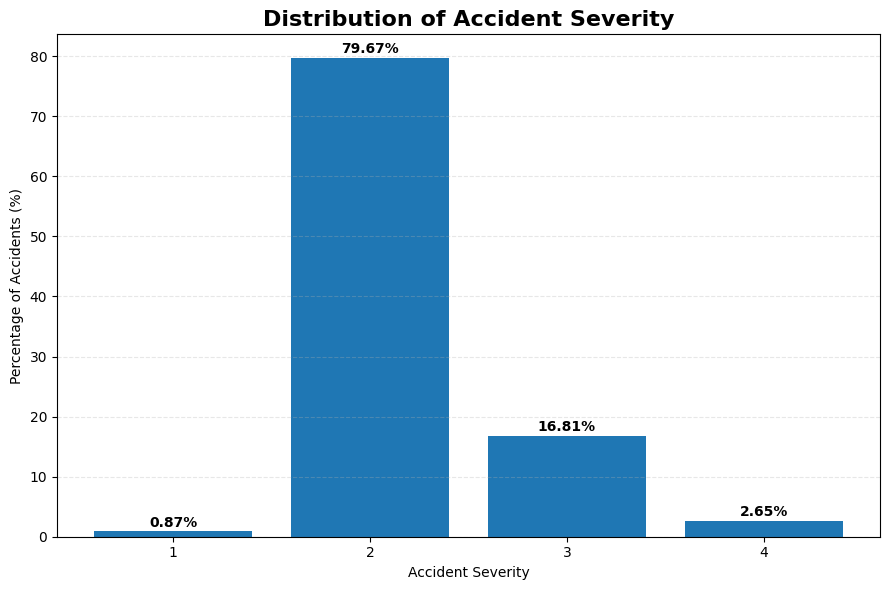

High-severity accidents (Severity 3 & 4): 1,504,047
High-severity percentage: 19.46%


In [ ]:
# ============================================================
# SEVERITY DISTRIBUTION
# ============================================================

severity_df = pd.DataFrame(
    [
        {
            "Severity": severity,
            "Accidents": count,
            "Percentage": (count / total_rows) * 100
        }
        for severity, count in severity_counts.items()
    ]
).sort_values("Severity")

plt.figure(figsize=(9, 6))

bars = plt.bar(
    severity_df["Severity"].astype(str),
    severity_df["Percentage"]
)

for bar, value in zip(
    bars,
    severity_df["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Distribution of Accident Severity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Accident Severity")
plt.ylabel("Percentage of Accidents (%)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

high_severity_total = (
    severity_counts.get(3, 0) +
    severity_counts.get(4, 0)
)

high_severity_percentage = (
    high_severity_total / total_rows
) * 100

print(
    f"High-severity accidents (Severity 3 & 4): "
    f"{high_severity_total:,}"
)

print(
    f"High-severity percentage: "
    f"{high_severity_percentage:.2f}%"
)

## 3. Accident Trends Over the Years

This analysis examines how the number of reported accidents changed over time.

Note: 2023 contains only a partial year of data and should not be directly compared with complete years.

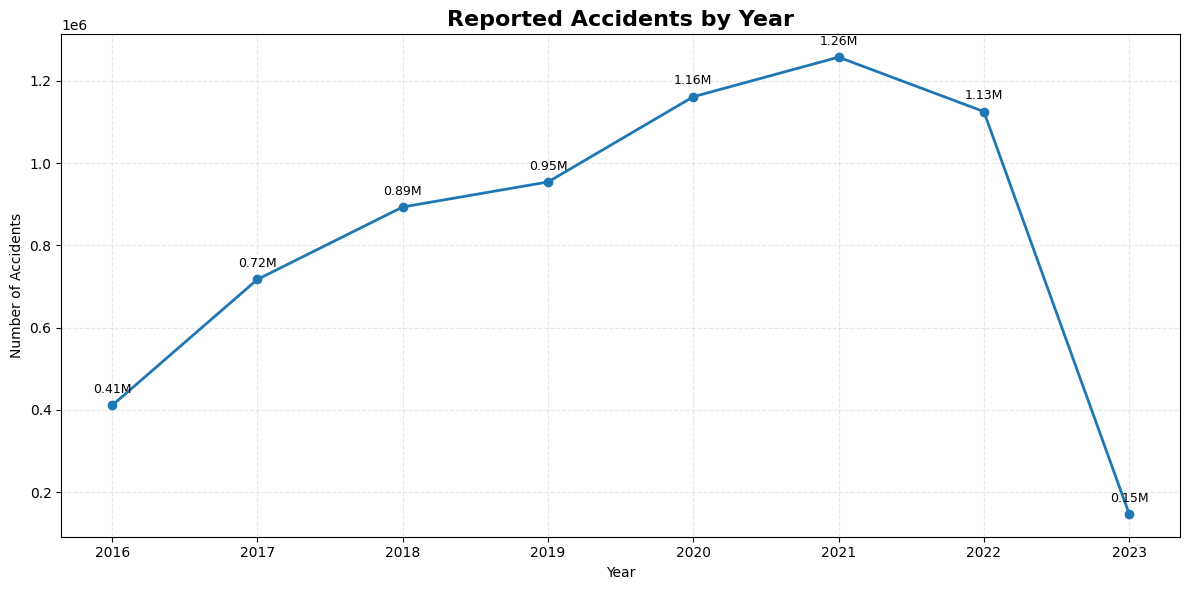

In [ ]:
# ============================================================
# ACCIDENTS BY YEAR
# ============================================================

year_counts = {}

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["Year"],
    chunksize=100_000,
    low_memory=False
):

    counts = chunk["Year"].value_counts()

    for year, count in counts.items():
        year_counts[year] = (
            year_counts.get(year, 0) + count
        )

year_df = (
    pd.DataFrame(
        list(year_counts.items()),
        columns=["Year", "Accidents"]
    )
    .sort_values("Year")
)

plt.figure(figsize=(12, 6))

plt.plot(
    year_df["Year"],
    year_df["Accidents"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    year_df["Year"],
    year_df["Accidents"]
):
    plt.text(
        x,
        y + 30000,
        f"{y/1e6:.2f}M",
        ha="center",
        fontsize=9
    )

plt.title(
    "Reported Accidents by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Accidents")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 4. Geographic Distribution by State

This analysis identifies the states with the highest number of reported accident records.

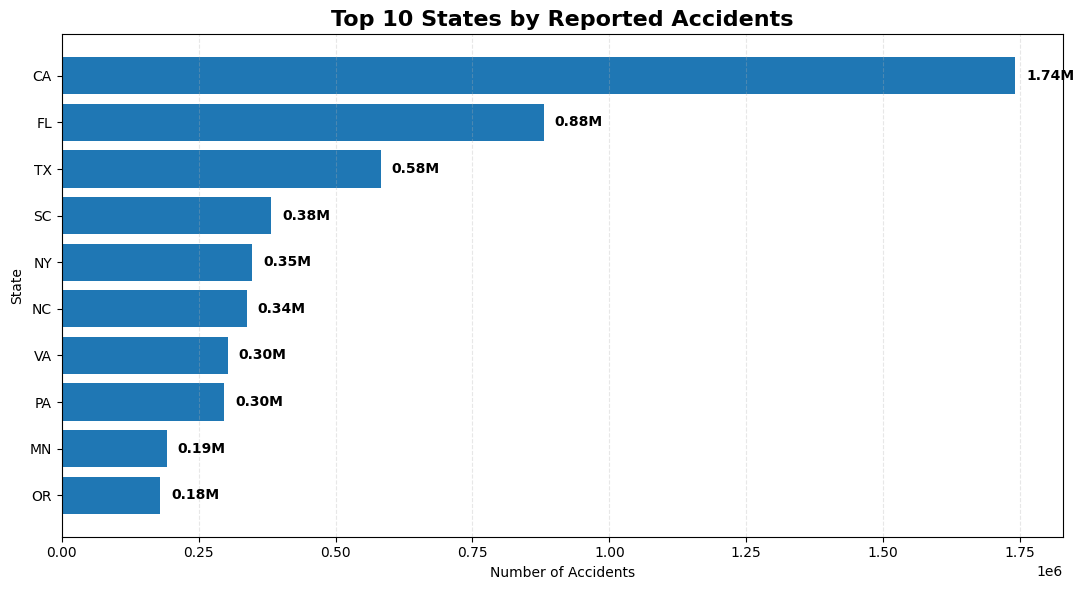

,State,Accidents
0,CA,1741433
3,FL,880192
20,TX,582837
9,SC,382557
8,NY,347960
29,NC,338199
22,VA,303301
19,PA,296620
35,MN,192084
27,OR,179660


In [ ]:
# ============================================================
# TOP STATES
# ============================================================

state_counts = {}

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["State"],
    chunksize=100_000,
    low_memory=False
):

    counts = chunk["State"].value_counts()

    for state, count in counts.items():
        state_counts[state] = (
            state_counts.get(state, 0) + count
        )

top_states = (
    pd.DataFrame(
        list(state_counts.items()),
        columns=["State", "Accidents"]
    )
    .sort_values("Accidents", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))

plot_df = top_states.sort_values("Accidents")

bars = plt.barh(
    plot_df["State"],
    plot_df["Accidents"]
)

for bar, value in zip(
    bars,
    plot_df["Accidents"]
):
    plt.text(
        value + 20000,
        bar.get_y() + bar.get_height()/2,
        f"{value/1e6:.2f}M",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Top 10 States by Reported Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("State")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

display(top_states)

## 5. Accident Distribution by Time of Day

This analysis identifies the hours when accidents are most frequently reported.

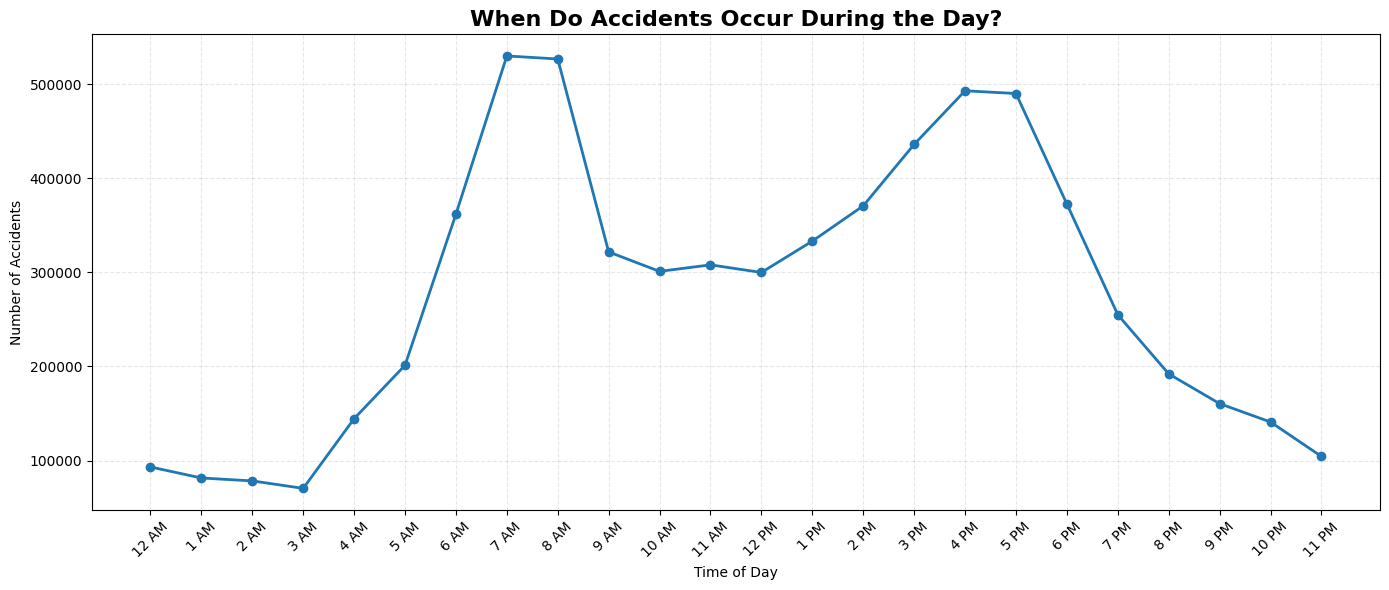

In [ ]:
# ============================================================
# ACCIDENTS BY HOUR
# ============================================================

hour_counts = {}

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["Hour"],
    chunksize=100_000,
    low_memory=False
):

    counts = chunk["Hour"].value_counts()

    for hour, count in counts.items():
        hour_counts[hour] = (
            hour_counts.get(hour, 0) + count
        )

hour_df = pd.DataFrame(
    [
        {
            "Hour": int(hour),
            "Accidents": count
        }
        for hour, count in hour_counts.items()
    ]
).sort_values("Hour")

# Human-friendly clock labels
def clock_label(hour):
    if hour == 0:
        return "12 AM"
    elif hour < 12:
        return f"{hour} AM"
    elif hour == 12:
        return "12 PM"
    else:
        return f"{hour-12} PM"

hour_df["Time"] = hour_df["Hour"].apply(clock_label)

plt.figure(figsize=(14, 6))

plt.plot(
    hour_df["Time"],
    hour_df["Accidents"],
    marker="o",
    linewidth=2
)

plt.title(
    "When Do Accidents Occur During the Day?",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 6. High-Severity Accident Windows

Instead of only looking at accident frequency, this analysis identifies the specific day-and-hour combinations where the proportion of high-severity accidents is highest.

High severity is defined as Severity 3 or 4.

In [ ]:
# ============================================================
# HIGH-SEVERITY ACCIDENT WINDOWS
# ============================================================

day_hour_results = []

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["Day_of_Week", "Hour", "Severity"],
    chunksize=100_000,
    low_memory=False
):

    chunk["High_Severity"] = chunk["Severity"].isin([3, 4])

    grouped = (
        chunk
        .groupby(["Day_of_Week", "Hour"])
        .agg(
            Total_Accidents=("Severity", "size"),
            High_Severity_Accidents=("High_Severity", "sum")
        )
        .reset_index()
    )

    day_hour_results.append(grouped)

day_hour_df = pd.concat(
    day_hour_results,
    ignore_index=True
)

day_hour_df = (
    day_hour_df
    .groupby(["Day_of_Week", "Hour"], as_index=False)
    .sum()
)

day_hour_df["High_Severity_Percentage"] = (
    day_hour_df["High_Severity_Accidents"] /
    day_hour_df["Total_Accidents"] *
    100
)

# Avoid very small groups
day_hour_df = day_hour_df[
    day_hour_df["Total_Accidents"] >= 1000
]

top_high_severity_windows = (
    day_hour_df
    .sort_values(
        "High_Severity_Percentage",
        ascending=False
    )
    .head(15)
)

display(top_high_severity_windows)

,Day_of_Week,Hour,Total_Accidents,High_Severity_Accidents,High_Severity_Percentage
79,Sunday,7.0,15745,5414,34.385519
55,Saturday,7.0,18429,6004,32.579087
80,Sunday,8.0,15410,4763,30.908501
56,Saturday,8.0,19619,6041,30.791580
78,Sunday,6.0,13742,4194,30.519575
85,Sunday,13.0,28360,8583,30.264457
87,Sunday,15.0,27471,8178,29.769575
88,Sunday,16.0,26675,7758,29.083411
86,Sunday,14.0,29208,8468,28.992057
84,Sunday,12.0,26605,7575,28.472092


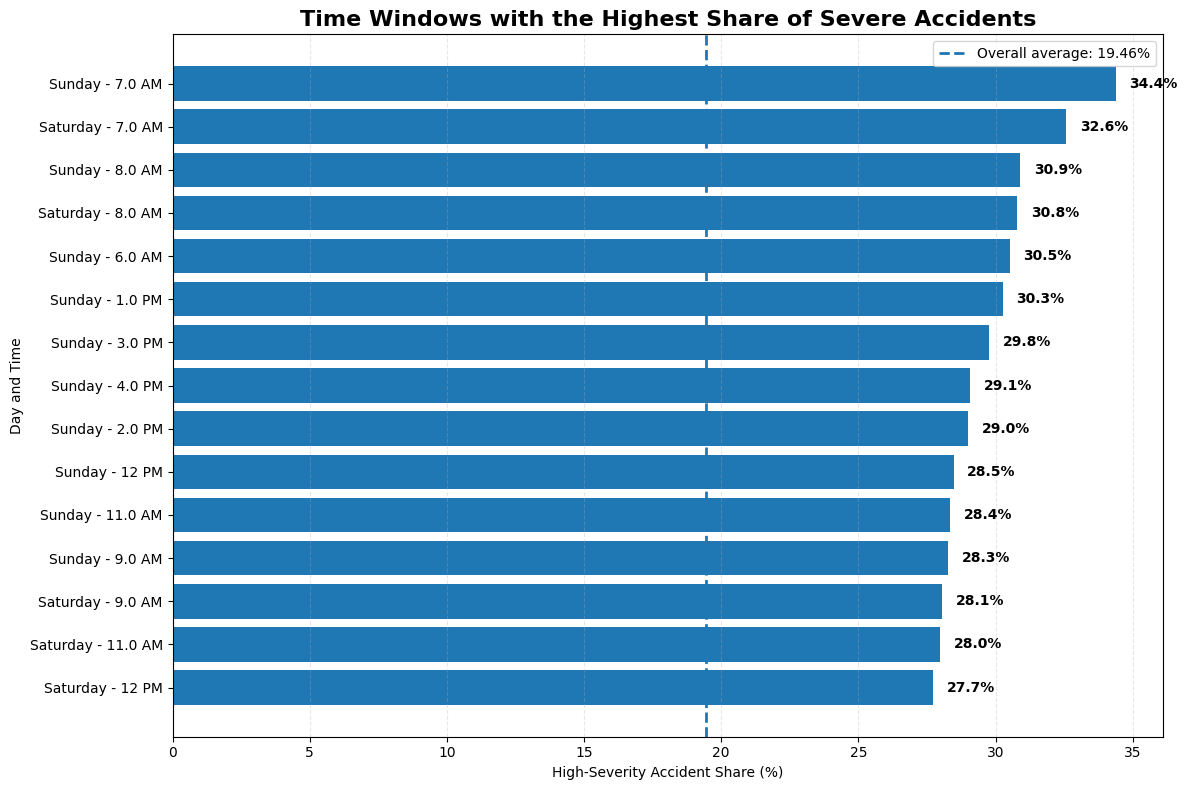

In [ ]:
# ============================================================
# TOP HIGH-SEVERITY TIME WINDOWS
# ============================================================

plot_df = top_high_severity_windows.copy()

plot_df["Window"] = (
    plot_df["Day_of_Week"] +
    " - " +
    plot_df["Hour"].apply(clock_label)
)

plot_df = plot_df.sort_values(
    "High_Severity_Percentage"
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["Window"],
    plot_df["High_Severity_Percentage"]
)

plt.axvline(
    high_severity_percentage,
    linestyle="--",
    linewidth=2,
    label=f"Overall average: {high_severity_percentage:.2f}%"
)

for bar, value in zip(
    bars,
    plot_df["High_Severity_Percentage"]
):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Time Windows with the Highest Share of Severe Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "High-Severity Accident Share (%)"
)

plt.ylabel("Day and Time")

plt.legend()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 7. Weather Conditions and Accident Severity

Weather conditions are compared with accident severity to identify conditions associated with a higher proportion of Severity 3 and 4 accidents.

This analysis represents association rather than causation.

In [ ]:
# ============================================================
# WEATHER × SEVERITY
# ============================================================

weather_results = []

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["Weather_Condition", "Severity"],
    chunksize=100_000,
    low_memory=False
):

    chunk["Weather_Condition"] = (
        chunk["Weather_Condition"]
        .fillna("Unknown")
        .astype(str)
    )

    chunk["High_Severity"] = chunk["Severity"].isin([3, 4])

    grouped = (
        chunk
        .groupby("Weather_Condition")
        .agg(
            Total_Accidents=("Severity", "size"),
            High_Severity_Accidents=("High_Severity", "sum")
        )
        .reset_index()
    )

    weather_results.append(grouped)

weather_df = pd.concat(
    weather_results,
    ignore_index=True
)

weather_df = (
    weather_df
    .groupby("Weather_Condition", as_index=False)
    .sum()
)

weather_df["High_Severity_Percentage"] = (
    weather_df["High_Severity_Accidents"] /
    weather_df["Total_Accidents"] *
    100
)

# Keep conditions with enough observations
weather_plot_df = weather_df[
    weather_df["Total_Accidents"] >= 1000
].sort_values(
    "High_Severity_Percentage",
    ascending=False
).head(15)

display(weather_plot_df)

,Weather_Condition,Total_Accidents,High_Severity_Accidents,High_Severity_Percentage
136,Thunderstorms and Rain,2217,963,43.437077
47,Heavy Thunderstorms and Rain,2485,1075,43.259557
80,Light Thunderstorms and Rain,4931,2030,41.168120
135,Thunderstorm,4438,1708,38.485804
106,Scattered Clouds,204829,72008,35.155178
88,Overcast,382866,133813,34.950348
57,Light Freezing Rain,3465,1178,33.997114
6,Clear,808743,271435,33.562578
56,Light Freezing Fog,1001,321,32.067932
55,Light Freezing Drizzle,1240,388,31.290323


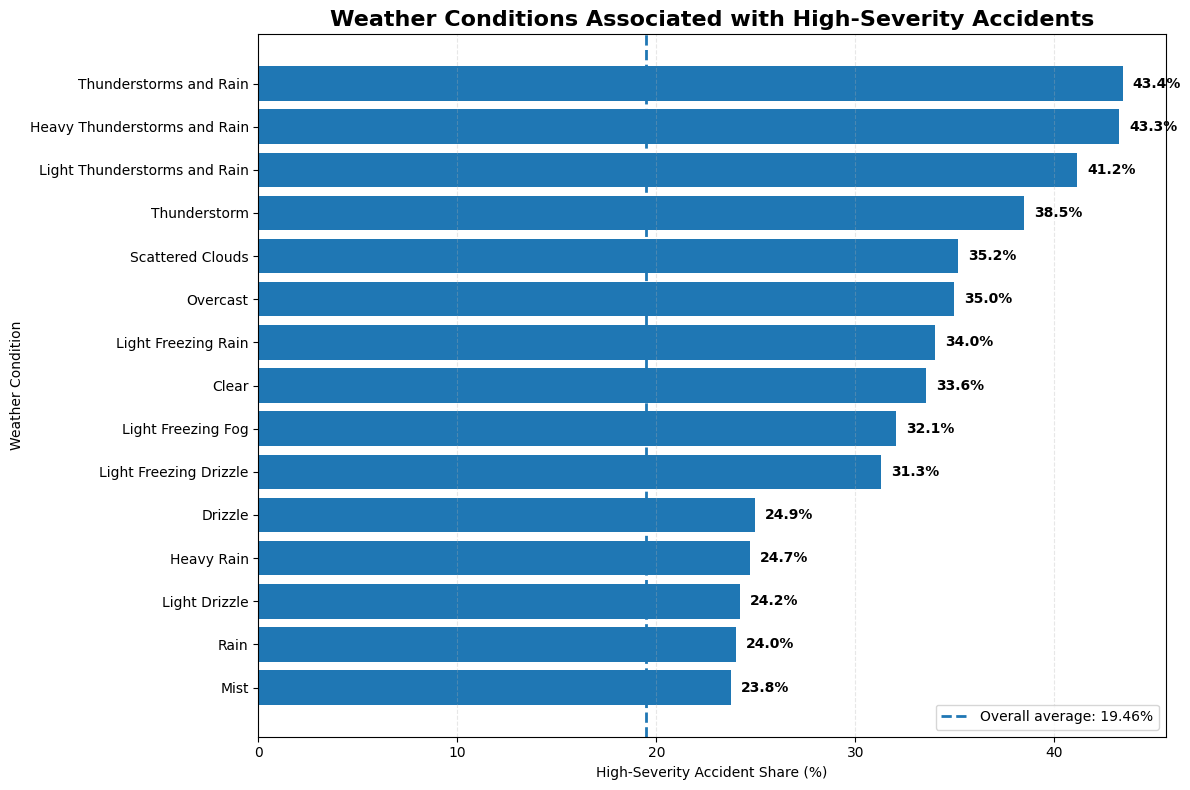

In [ ]:
# ============================================================
# TOP WEATHER CONDITIONS BY HIGH-SEVERITY SHARE
# ============================================================

plot_df = weather_plot_df.sort_values(
    "High_Severity_Percentage"
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["Weather_Condition"],
    plot_df["High_Severity_Percentage"]
)

plt.axvline(
    high_severity_percentage,
    linestyle="--",
    linewidth=2,
    label=f"Overall average: {high_severity_percentage:.2f}%"
)

for bar, value in zip(
    bars,
    plot_df["High_Severity_Percentage"]
):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Weather Conditions Associated with High-Severity Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("High-Severity Accident Share (%)")
plt.ylabel("Weather Condition")

plt.legend()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 8. Accident Circumstance Analysis Using Description

The dataset does not contain a dedicated standardized accident-cause column.

Therefore, selected keywords and phrases from the Description field are used to identify reported circumstances such as lane blockage, traffic congestion, ramp incidents, collisions, weather-related mentions, and emergency response.

These categories represent reported circumstances and should not be interpreted as confirmed causes.

In [ ]:
# ============================================================
# ACCIDENT CIRCUMSTANCES FROM DESCRIPTION
# ============================================================

circumstance_patterns = {
    "Lane Blockage": [
        "lane blocked",
        "lanes blocked",
        "lane closed",
        "lanes closed",
        "one lane",
        "two lanes",
        "center lane"
    ],

    "Shoulder Blockage": [
        "shoulder blocked",
        "shoulder closed"
    ],

    "Traffic Congestion / Delays": [
        "slow traffic",
        "stationary traffic",
        "traffic delays",
        "expect delays",
        "long delays",
        "traffic jam",
        "traffic backed"
    ],

    "Vehicle Crash / Collision": [
        "vehicle crash",
        "crash",
        "collision"
    ],

    "Ramp / Exit Incident": [
        "entry ramp",
        "exit ramp",
        "ramp closed",
        "exit closed"
    ],

    "Construction / Road Work": [
        "construction",
        "road work",
        "work zone",
        "maintenance"
    ],

    "Weather Related": [
        "rain",
        "snow",
        "fog",
        "ice",
        "storm",
        "thunderstorm",
        "flood",
        "hail"
    ],

    "Emergency / Response": [
        "police",
        "fire",
        "emergency",
        "rescue"
    ],

    "Stationary / Disabled Vehicle": [
        "stationary vehicle",
        "disabled vehicle",
        "stopped vehicle"
    ]
}

circumstance_counts = {
    category: 0
    for category in circumstance_patterns
}

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["Description"],
    chunksize=100_000,
    low_memory=False
):

    description = (
        chunk["Description"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    for category, keywords in circumstance_patterns.items():

        pattern = "|".join(
            [k.replace(" ", r"\s+") for k in keywords]
        )

        matches = description.str.contains(
            pattern,
            regex=True,
            na=False
        )

        circumstance_counts[category] += matches.sum()

circumstance_df = (
    pd.DataFrame(
        list(circumstance_counts.items()),
        columns=["Circumstance", "Accidents"]
    )
    .sort_values("Accidents", ascending=False)
)

circumstance_df["Percentage"] = (
    circumstance_df["Accidents"] /
    total_rows *
    100
)

display(circumstance_df)

,Circumstance,Accidents,Percentage
2,Traffic Congestion / Delays,1616963,20.922368
0,Lane Blockage,1460563,18.898661
1,Shoulder Blockage,434251,5.618903
3,Vehicle Crash / Collision,431935,5.588936
4,Ramp / Exit Incident,122560,1.585840
6,Weather Related,66333,0.858303
7,Emergency / Response,27367,0.354110
5,Construction / Road Work,19014,0.246028
8,Stationary / Disabled Vehicle,6385,0.082617


## 9. Accident Circumstances Associated with High Severity

The identified accident circumstances are compared with the proportion of Severity 3 and 4 accidents.

This helps distinguish between circumstances that are frequently reported and those that are more strongly associated with high severity.

The categories may overlap because one accident description can mention multiple circumstances.

In [ ]:
# ============================================================
# CIRCUMSTANCE × SEVERITY
# ============================================================

circumstance_severity_results = []

usecols = ["Description", "Severity"]

for chunk in pd.read_csv(
    feature_output_path,
    usecols=usecols,
    chunksize=100_000,
    low_memory=False
):

    description = (
        chunk["Description"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    high_severity = chunk["Severity"].isin([3, 4])

    for category, keywords in circumstance_patterns.items():

        pattern = "|".join(
            [k.replace(" ", r"\s+") for k in keywords]
        )

        mask = description.str.contains(
            pattern,
            regex=True,
            na=False
        )

        total = mask.sum()
        high = (high_severity & mask).sum()

        circumstance_severity_results.append({
            "Circumstance": category,
            "Total_Accidents": total,
            "High_Severity_Accidents": high
        })

circumstance_severity_df = (
    pd.DataFrame(circumstance_severity_results)
    .groupby("Circumstance", as_index=False)
    .sum()
)

circumstance_severity_df["High_Severity_Percentage"] = (
    circumstance_severity_df["High_Severity_Accidents"] /
    circumstance_severity_df["Total_Accidents"] *
    100
)

circumstance_severity_df = (
    circumstance_severity_df
    .sort_values(
        "High_Severity_Percentage",
        ascending=False
    )
)

display(circumstance_severity_df)

,Circumstance,Total_Accidents,High_Severity_Accidents,High_Severity_Percentage
3,Ramp / Exit Incident,122560,72281,58.976012
2,Lane Blockage,1460563,752335,51.509931
4,Shoulder Blockage,434251,191644,44.132080
1,Emergency / Response,27367,7948,29.042277
0,Construction / Road Work,19014,4025,21.168613
7,Vehicle Crash / Collision,431935,89415,20.701031
8,Weather Related,66333,11601,17.489033
6,Traffic Congestion / Delays,1616963,30079,1.860216
5,Stationary / Disabled Vehicle,6385,40,0.626468


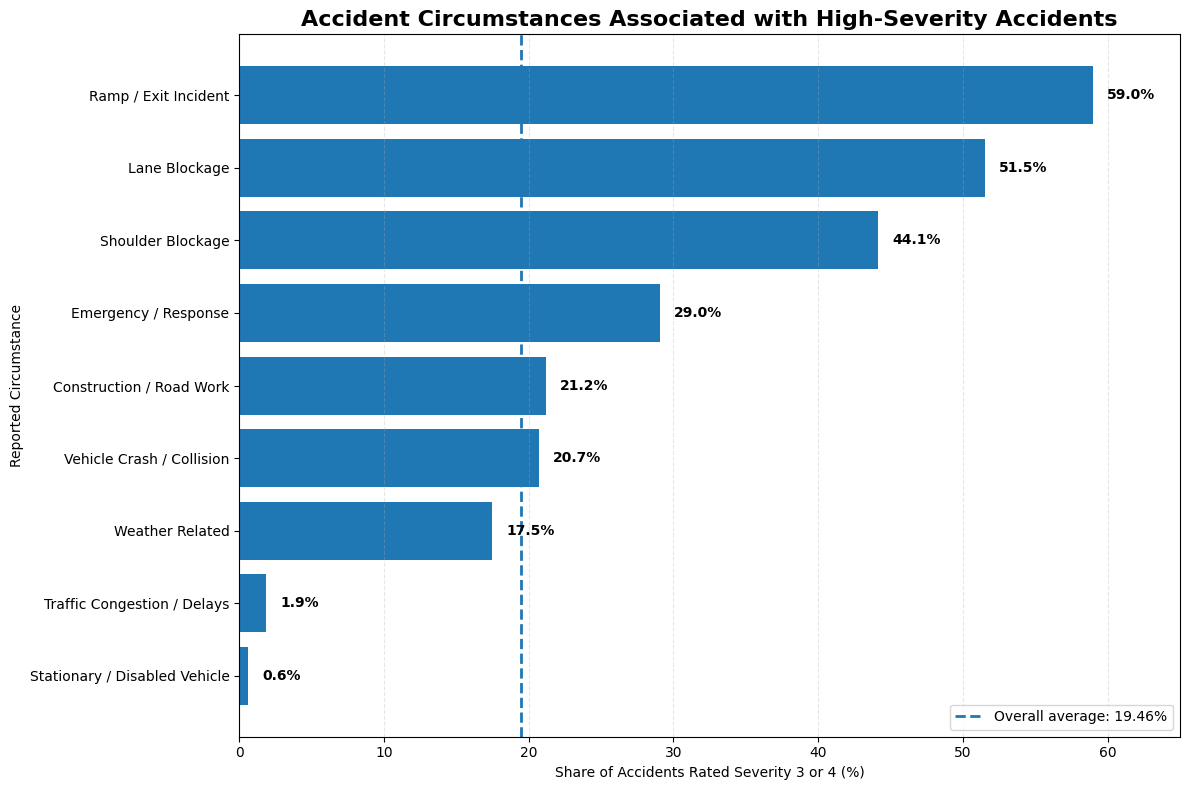

In [ ]:
# ============================================================
# CIRCUMSTANCE SEVERITY GRAPH
# ============================================================

plot_df = circumstance_severity_df.sort_values(
    "High_Severity_Percentage"
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["Circumstance"],
    plot_df["High_Severity_Percentage"]
)

plt.axvline(
    high_severity_percentage,
    linestyle="--",
    linewidth=2,
    label=f"Overall average: {high_severity_percentage:.2f}%"
)

for bar, value in zip(
    bars,
    plot_df["High_Severity_Percentage"]
):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Accident Circumstances Associated with High-Severity Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Share of Accidents Rated Severity 3 or 4 (%)"
)

plt.ylabel("Reported Circumstance")

plt.xlim(0, 65)

plt.legend()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 13. Geographic Accident Hotspots

This analysis identifies cities with the largest number of reported accident records.

These locations can be considered accident-reporting hotspots within the dataset.

In [ ]:
# ============================================================
# TOP ACCIDENT CITIES
# ============================================================

city_counts = {}

for chunk in pd.read_csv(
    feature_output_path,
    usecols=["City", "State"],
    chunksize=100_000,
    low_memory=False
):

    chunk["City"] = (
        chunk["City"]
        .fillna("Unknown")
        .astype(str)
    )

    grouped = (
        chunk
        .groupby(["City", "State"])
        .size()
    )

    for (city, state), count in grouped.items():

        key = (city, state)

        city_counts[key] = (
            city_counts.get(key, 0) + count
        )

top_cities = (
    pd.DataFrame(
        [
            {
                "City": city,
                "State": state,
                "Accidents": count
            }
            for (city, state), count in city_counts.items()
        ]
    )
    .sort_values(
        "Accidents",
        ascending=False
    )
    .head(20)
)

display(top_cities)

,City,State,Accidents
2012,Miami,FL,186768
3713,Houston,TX,169428
375,Los Angeles,CA,156491
5821,Charlotte,NC,138345
3390,Dallas,TX,130303
2270,Orlando,FL,109690
3100,Austin,TX,96604
7860,Raleigh,NC,86066
7475,Nashville,TN,72670
5474,Baton Rouge,LA,71588


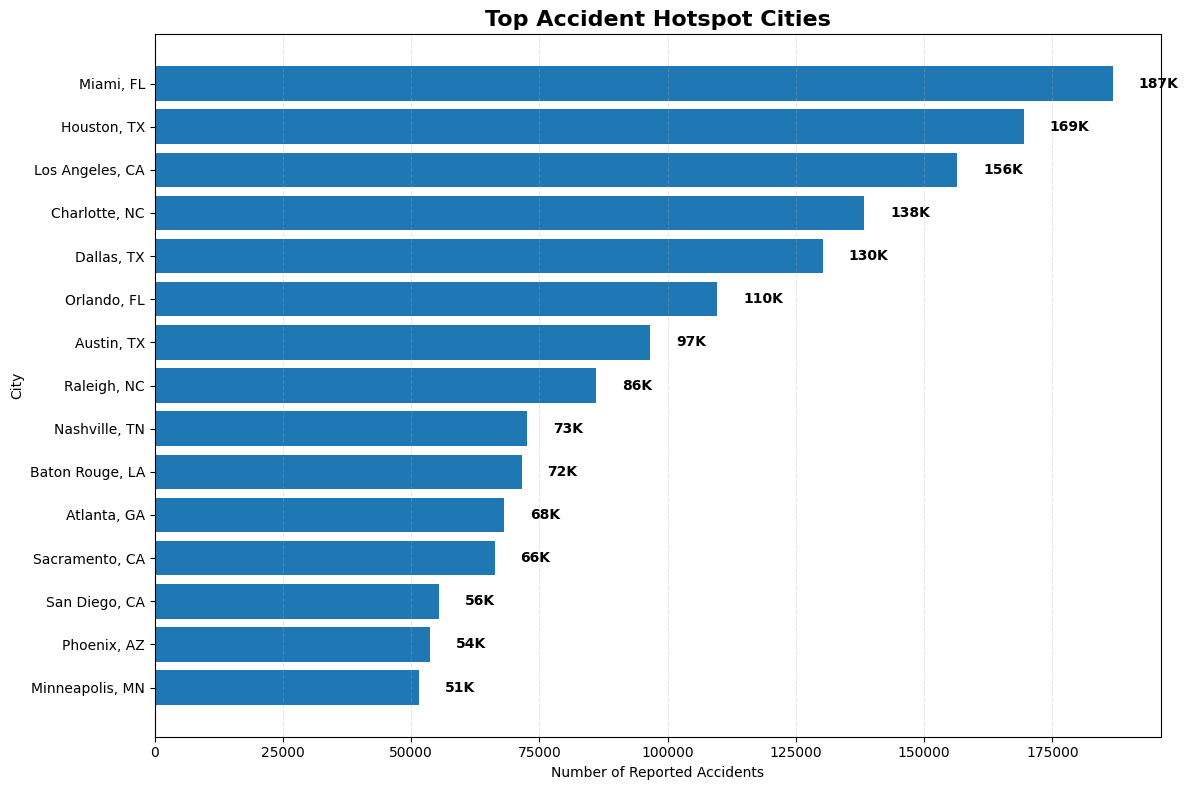

In [ ]:
# ============================================================
# TOP 15 CITIES GRAPH
# ============================================================

plot_df = top_cities.head(15).copy()

plot_df["Location"] = (
    plot_df["City"] +
    ", " +
    plot_df["State"]
)

plot_df = plot_df.sort_values("Accidents")

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["Location"],
    plot_df["Accidents"]
)

for bar, value in zip(
    bars,
    plot_df["Accidents"]
):
    plt.text(
        value + 5000,
        bar.get_y() + bar.get_height()/2,
        f"{value/1000:.0f}K",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Top Accident Hotspot Cities",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Reported Accidents")
plt.ylabel("City")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE IMPORTANT INSIGHT GRAPHS
# ============================================================

import os

insight_folder = "/content/accident_data/insight_pngs"

os.makedirs(
    insight_folder,
    exist_ok=True
)

print("Insight folder created:")
print(insight_folder)
print("\nYou can save each final graph using:")
print("plt.savefig(path, dpi=300, bbox_inches='tight')")

Insight folder created:
/content/accident_data/insight_pngs

You can save each final graph using:
plt.savefig(path, dpi=300, bbox_inches='tight')


In [ ]:
import os
import shutil
from google.colab import files

insight_folder = "/content/accident_data/insight_pngs"
zip_base = "/content/US_Accidents_Insight_Graphs"

# Check whether PNGs actually exist
png_files = [
    f for f in os.listdir(insight_folder)
    if f.lower().endswith(".png")
]

print(f"Found {len(png_files)} PNG files:")

for f in sorted(png_files):
    print("✔", f)

# Create ZIP
shutil.make_archive(
    zip_base,
    "zip",
    insight_folder
)

zip_path = zip_base + ".zip"

print("\n✅ ZIP created successfully!")
print(zip_path)

# Download directly
files.download(zip_path)

Found 0 PNG files:

✅ ZIP created successfully!
/content/US_Accidents_Insight_Graphs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>